In [1]:
# Repo-root bootstrap: find the directory containing the `llm_perf` package
# (walking up from CWD) and chdir there so paths like "llm_perf/database/..."
# and "assets/..." resolve regardless of where the notebook lives on disk.
import os
from pathlib import Path
_p = Path.cwd()
while not (_p / "llm_perf" / "__init__.py").exists():
    if _p == _p.parent:
        raise RuntimeError("Could not find llm_perf repo root from " + str(Path.cwd()))
    _p = _p.parent
os.chdir(_p)
print("cwd:", Path.cwd())

cwd: /Users/jasonlu/Projects/ai.cluster/llm_perf


# Partition-Optimal Pareto Frontiers vs. Memory First-Byte Latency $\alpha_{\mathrm{mem}}$

**Question:** how much does the per-tier first-byte memory latency $\alpha_{\mathrm{mem}}$ shift the (throughput/GPU, interactivity) Pareto frontier on GB200 NVL72 with NVLS / SHARP in-network collectives **on**, across the magnitude range that on-die / co-packaged tiers actually inhabit (SRAM ~1 ns, HBM ~10 ns, LPDDR5 ~200 ns, stretched-DRAM worst-case ~300 ns)?

**Why $\alpha_{\mathrm{mem}}$:** the multi-tier decode roofline `documentation/modeling/sram.md §2.1` is the standard $\alpha$–$\beta$ form,

$$t_{\mathrm{mem}}(B) \;=\; \sum_i \Big[\, \alpha_i \cdot \mathbb{1}(\mathrm{bytes}_i > 0) \;+\; \frac{T_{\theta,i} + B \cdot T_{\mathrm{KV},i}}{BW_{\mathrm{eff},i}}\,\Big]$$

with one transaction per non-empty tier per step. For on-die / co-packaged tiers $\alpha_i$ falls in the 1–300 ns range, while the bytes term lands in 10 µs–1 ms — so the magnitude argument predicts the term contributes well under 0.1% of $t_{\mathrm{mem}}$ and the Pareto frontier should be **insensitive** to $\alpha_{\mathrm{mem}}$ in this regime. This notebook is the empirical check.

**INC on:** the system loads `gb200.nvl72.nvls.json` with NVLink SHARP enabled (`inc_enabled=True`, the tuner default). NVLS collapses AR/AG `n_α` to 2 and doubles BW_eff for AR — so the comm term is at its hardware floor and any frontier sensitivity here is attributable to the device-side $\alpha_{\mathrm{mem}}$.

Model, system, and tuner are configured in Section 1 — swap the database paths there to study a different setup.

## 1. Imports and spec loading

In [ ]:
from __future__ import annotations

import math
from copy import deepcopy
from dataclasses import dataclass

import matplotlib.pyplot as plt

from llm_perf import InferenceCalculator
from llm_perf.core.collective_algo_opt import optimize_collective_algorithms
from llm_perf.core.kv_paging_model import KVPagingConfig, compute_kv_paging
from llm_perf.core.memory_model import compute_memory
from llm_perf.io import load_model_spec, load_system_spec, load_tuning_spec
from llm_perf.specs.framework_spec import FrameworkSpec
from llm_perf.specs.partition_spec import PartitionSpec
from llm_perf.specs.system_spec import MemoryTierSpec, span_tiers

# Configuration — GPT-1.8T MoE @ FP4 on GB200 NVL72 with NVLS / SHARP
# in-network collectives ENABLED on the FrameworkSpec (Phase E moved
# `inc_enabled` and the algorithm fields off TuningSpec).
MODEL = "llm_perf/database/model/gpt_1_8t_moe.json"
SYSTEM = "llm_perf/database/system/gb200.nvl72.nvls.json"
TUNER = "llm_perf/database/tuner/gpt_1_8t_moe.tuner.json"

S_DECODE = 8192
BPP_FP4 = 0.5

model = load_model_spec(MODEL)
model.bytes_per_param = BPP_FP4
system = load_system_spec(SYSTEM)
tuner_base = load_tuning_spec(TUNER)
tuner_base.S_decode = S_DECODE
tuner_base.B_decode = 1

framework_base = FrameworkSpec(
    name="gb200_nvls",
    tp_algorithm_decode="auto", tp_algorithm_prefill="auto",
    ep_algorithm_decode="auto", ep_algorithm_prefill="auto",
    inc_enabled=True,
)
assert framework_base.inc_enabled, "INC must stay enabled for this notebook"

hbm_tier0 = system.device.get_tiers()[0]
fab_alpha, fab_bw, _ = span_tiers(system.get_tier_chain('TP'), 2)
tier0 = system.fabrics['nvlink5'].tiers[0]
print(f"Model:  {model.name}  L={model.L}  H={model.H}  n_kv={model.n_kv}  experts={model.moe.n_experts}  k_active={model.moe.k_active}  bytes/param={model.bytes_per_param}")
print(f"System: {system.num_devices} GPUs  HBM={hbm_tier0.bandwidth_GBps:.0f} GB/s  cap={hbm_tier0.capacity_GB:.0f} GB  base α_mem={hbm_tier0.alpha_us*1e3:.1f} ns")
print(f"        scale-up: {fab_bw:.0f} GB/s · {fab_alpha:.2f} μs sw α  |  INC: {tier0.inc!r} @ {tier0.inc_alpha_us:.2f} μs hw α")

## 2. Partition enumeration

Same constraints as `pareto_vs_kernel_launch` / `pareto_basic`:

- **`PP ≤ 8`** — operational cap. Library default is 32; pinned to 8 here.
- `TP ≤ min(n_kv, n_experts) = 16`.
- `EP ≤ n_experts = 16`.
- `TP · EP ≤ scale_up_domain` (NVL72 → 72 ranks, single tier).
- `SP ∈ [1, 2, 4, 8, 16, 32, 64]`.
- `PP · TP · EP · SP ≤ num_devices = 72`.

In [3]:
PP_MAX = 8   # Operational cap; raise to 32 for unbounded-PP analysis.

from llm_perf.utils import (
    enumerate_partitions as _enumerate_partitions,
    describe_constraints,
)


def enumerate_partitions(num_devices: int) -> list[PartitionSpec]:
    """Local shim around llm_perf.utils.enumerate_partitions; pins (model, system, pp_max)."""
    return _enumerate_partitions(model, system, num_devices=num_devices, pp_max=PP_MAX)


print(describe_constraints(model, system, pp_max=PP_MAX))

partitions = enumerate_partitions(system.num_devices)
print(f"Valid partitions: {len(partitions)}")

PP ≤ 8; TP ≤ min(n_kv=16, n_experts=16) = 16; EP ≤ n_experts=16; TP·EP ≤ scale_up=72 (tier_idx=0)
Valid partitions: 260


## 3. Partition sweep — one full sweep per $\alpha_{\mathrm{mem}}$ anchor

Each $\alpha_{\mathrm{mem}}$ anchor maps onto a memory-technology magnitude. For each anchor we override the device's tier list with a single HBM tier carrying the chosen $\alpha$, then re-run the full (partition, B) sweep.

| $\alpha_{\mathrm{mem}}$ | Tier-tech regime |
|---|---|
| **0 ns**   | Pure-roofline baseline (β-only). |
| **100 ns** | HBM3 / HBM3e first-byte (refresh + row activation amortized). |
| **200 ns** | LPDDR5 first-byte. |
| **300 ns** | Stretched-DRAM worst-case / lightly-tuned LPDDR. |

Within the magnitude argument of `sram.md §2.1` these all sit well below the per-step bytes term (10 µs – 1 ms scale), so the frontier shifts should be visually negligible. The notebook's job is to **show** that empirically across the partition envelope rather than just argue it from magnitudes.

In [ ]:
@dataclass
class Point:
    partition: PartitionSpec
    B: int
    tput_per_gpu: float
    interactivity: float
    TPOT_ms: float
    t_mem_ms: float

    @property
    def part_label(self) -> str:
        p = self.partition
        return f"PP={p.PP} TP={p.TP} EP={p.EP} SP={p.SP}"


def log_spaced_batch_sizes(b_max: int) -> list[int]:
    if b_max <= 1:
        return [1]
    n = max(int(math.log10(b_max) * 10), 16)
    raw = {1, b_max}
    for i in range(n + 1):
        raw.add(max(1, int(round(10 ** (i * math.log10(b_max) / n)))))
    p = 1
    while p <= b_max:
        raw.add(p)
        p *= 2
    return sorted(raw)


def system_with_alpha(system_template, alpha_ns: float):
    """Deepcopy `system_template` and replace device.tiers with a single HBM tier
    carrying `alpha_ns` first-byte latency. Capacity, BW, eta_beta preserved."""
    s = deepcopy(system_template)
    base_tier = s.device.get_tiers()[0]
    s.device.tiers = [MemoryTierSpec(
        name=base_tier.name,
        capacity_GB=base_tier.capacity_GB,
        bandwidth_GBps=base_tier.bandwidth_GBps,
        alpha_us=alpha_ns / 1e3,
        eta_beta=base_tier.eta_beta,
    )]
    return s


def sweep_partition(model, system, partition, tuner_template, framework_template) -> list[Point]:
    """Run the calculator at every B for one partition."""
    try:
        mem = compute_memory(model, system, partition, tuner_template, framework_template)
    except Exception:
        return []
    paging = KVPagingConfig(block_size=16, beam_width=1, system_overhead_GB=1.5)
    kv = compute_kv_paging(model, system, partition, tuner_template, framework_template, mem, paging)
    b_max = int(kv.max_sequences)
    if b_max < 1:
        return []
    replica = partition.PP * partition.TP * partition.EP * partition.SP
    DP = max(1, system.num_devices // replica)
    pts: list[Point] = []
    for B in log_spaced_batch_sizes(b_max):
        tuner = deepcopy(tuner_template)
        tuner.B_decode = B
        framework = optimize_collective_algorithms(model, partition, system, tuner, framework_template)
        try:
            r = InferenceCalculator(model, system, partition, tuner, framework).run()
        except Exception:
            continue
        if r.latency.TPOT <= 0:
            continue
        pts.append(Point(
            partition=partition, B=B,
            tput_per_gpu=(B * DP) / (r.latency.TPOT * system.num_devices),
            interactivity=1.0 / r.latency.TPOT,
            TPOT_ms=r.latency.TPOT * 1e3,
            t_mem_ms=r.latency.t_mem * 1e3,
        ))
    return pts


def pareto_frontier(points: list[Point]) -> list[Point]:
    sorted_pts = sorted(points, key=lambda p: (-p.tput_per_gpu, -p.interactivity))
    frontier: list[Point] = []
    best_interact = -math.inf
    for p in sorted_pts:
        if p.interactivity > best_interact + 1e-9:
            frontier.append(p)
            best_interact = p.interactivity
    frontier.sort(key=lambda p: p.tput_per_gpu)
    return frontier

In [ ]:
# alpha_mem anchors (ns) → memory-tier technology regime.
ALPHA_NS = [0, 100, 200, 300]

am_frontiers: dict[float, list[Point]] = {}
am_clouds:    dict[float, list[Point]] = {}
for alpha_ns in ALPHA_NS:
    sys_anchor = system_with_alpha(system, alpha_ns)
    cloud: list[Point] = []
    for part in partitions:
        cloud.extend(sweep_partition(model, sys_anchor, part, tuner_base, framework_base))
    fr = pareto_frontier(cloud)
    am_clouds[alpha_ns]    = cloud
    am_frontiers[alpha_ns] = fr
    if fr:
        contrib = [(alpha_ns * 1e-9) / (p.TPOT_ms * 1e-3) for p in fr]
        contrib.sort()
        med = contrib[len(contrib) // 2]
        print(f"α_mem = {alpha_ns:>3d} ns  |  cloud={len(cloud):>5d}  frontier={len(fr):>3d}  median α/TPOT on frontier = {med*100:.5f}%")
    else:
        print(f"α_mem = {alpha_ns:>3d} ns  |  cloud={len(cloud):>5d}  frontier=0")

## 4. Winners summary

Does the per-corner winner change with $\alpha_{\mathrm{mem}}$? If $\alpha_{\mathrm{mem}}$ is structurally negligible at these magnitudes, the partition-winner table should be **identical** across anchors.

In [6]:
def winners(frontier: list[Point]) -> list[tuple[str, int]]:
    counts: dict[str, int] = {}
    for p in frontier:
        counts[p.part_label] = counts.get(p.part_label, 0) + 1
    return sorted(counts.items(), key=lambda kv: -kv[1])


for alpha_ns, fr in am_frontiers.items():
    w = winners(fr)
    top = ", ".join(f"{k} ({v})" for k, v in w)
    head = f"α_mem = {alpha_ns:>3d} ns" + ("  (β-only baseline)" if alpha_ns == 0 else "")
    print(f"  {head}")
    print(f"    winners: {top}")

  α_mem =   0 ns  (β-only baseline)
    winners: PP=8 TP=8 EP=1 SP=1 (35), PP=4 TP=16 EP=1 SP=1 (3), PP=6 TP=4 EP=1 SP=1 (2)
  α_mem = 100 ns
    winners: PP=8 TP=8 EP=1 SP=1 (35), PP=4 TP=16 EP=1 SP=1 (3), PP=6 TP=4 EP=1 SP=1 (2)
  α_mem = 200 ns
    winners: PP=8 TP=8 EP=1 SP=1 (35), PP=4 TP=16 EP=1 SP=1 (3), PP=6 TP=4 EP=1 SP=1 (2)
  α_mem = 300 ns
    winners: PP=8 TP=8 EP=1 SP=1 (35), PP=4 TP=16 EP=1 SP=1 (3), PP=6 TP=4 EP=1 SP=1 (2)


## 5. Pareto plot

X = interactivity (1/TPOT), Y = throughput/GPU. The four curves should sit on top of each other across the visible range — the test of the magnitude argument.

Saved -> assets/pareto_vs_mem_alpha.png


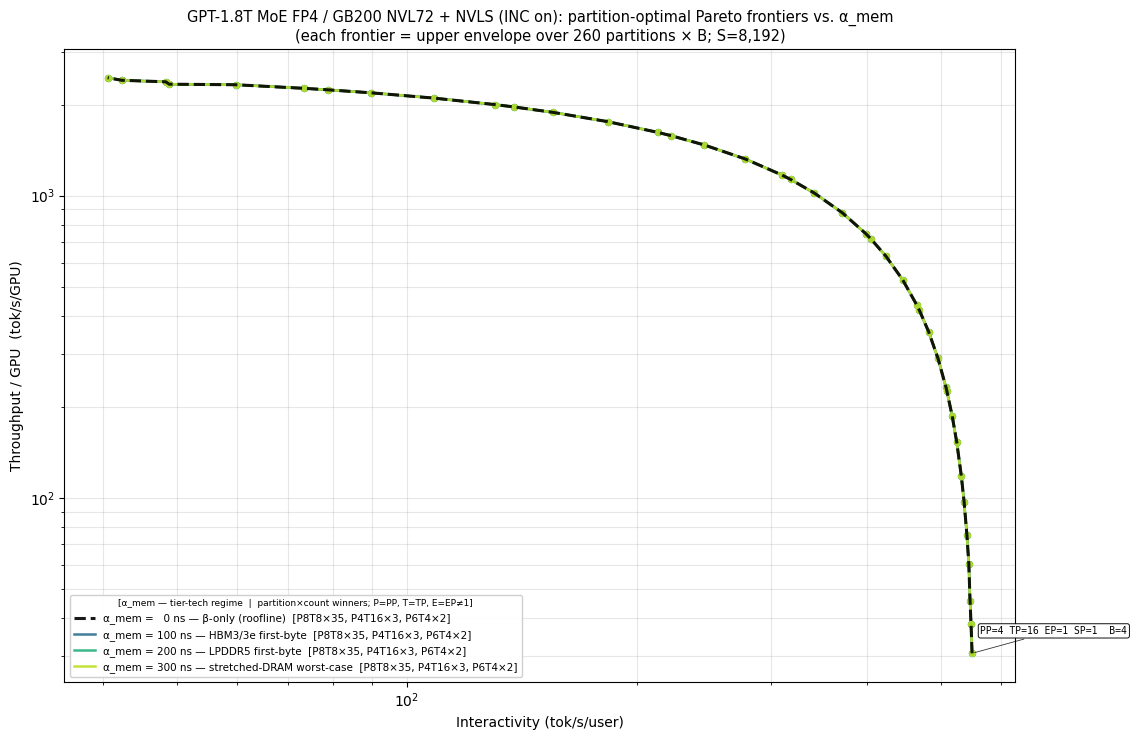

In [7]:
def winners_tag(frontier: list[Point]) -> str:
    counts: dict[str, int] = {}
    for p in frontier:
        counts[p.part_label] = counts.get(p.part_label, 0) + 1
    def short(name: str) -> str:
        return (name.replace(" EP=1", "").replace(" SP=1", "")
                    .replace("PP=", "P").replace("TP=", "T")
                    .replace("EP=", "E").replace(" ", ""))
    items = sorted(counts.items(), key=lambda kv: -kv[1])
    return ", ".join(f"{short(k)}×{v}" for k, v in items)


TIER_TAG: dict[float, str] = {
    0:   "β-only (roofline)",
    100: "HBM3/3e first-byte",
    200: "LPDDR5 first-byte",
    300: "stretched-DRAM worst-case",
}


def annotate_baseline(ax, frontier, color="black"):
    if not frontier:
        return
    seen: set[str] = set()
    picks: list[int] = []
    for i, p in enumerate(frontier):
        if p.part_label not in seen:
            seen.add(p.part_label); picks.append(i)
    min_dx = 0.05 * max((p.interactivity for p in frontier), default=1.0)
    last_x = -math.inf
    kept: list[int] = []
    for idx in picks:
        x = frontier[idx].interactivity
        if x - last_x >= min_dx:
            kept.append(idx); last_x = x
    offsets = [(6, 14), (6, -20), (6, 32), (6, -38)]
    for j, idx in enumerate(kept):
        p = frontier[idx]
        dx, dy = offsets[j % len(offsets)]
        ax.annotate(
            f"{p.part_label}  B={p.B}",
            xy=(p.interactivity, p.tput_per_gpu),
            xytext=(dx, dy), textcoords="offset points",
            fontsize=7, family="monospace", color="black", ha="left",
            bbox=dict(boxstyle="round,pad=0.22", fc="white",
                      ec=color, alpha=0.95, lw=0.7),
            arrowprops=dict(arrowstyle="-", color=color, lw=0.6, alpha=0.8),
        )


fig, ax = plt.subplots(figsize=(11.5, 7.5))
cmap = plt.get_cmap("viridis")
anchors = list(am_frontiers.keys())
colors = [cmap(0.10 + 0.80 * i / max(1, len(anchors) - 1)) for i in range(len(anchors))]


def legend_label(alpha_ns: int, fr: list[Point]) -> str:
    tag = TIER_TAG.get(alpha_ns, "")
    return f"α_mem = {alpha_ns:>3d} ns — {tag}  [{winners_tag(fr)}]"


# Baseline (α=0) drawn as dashed black reference.
zero_fr = am_frontiers.get(0, [])
if zero_fr:
    ax.plot([p.interactivity for p in zero_fr],
            [p.tput_per_gpu for p in zero_fr],
            "--", lw=2.2, color="black", alpha=0.9,
            label=legend_label(0, zero_fr), zorder=6)

for (alpha_ns, fr), color in zip(am_frontiers.items(), colors):
    if not fr or alpha_ns == 0:
        continue
    xs = [p.interactivity for p in fr]
    ys = [p.tput_per_gpu for p in fr]
    ax.plot(xs, ys, "-", lw=1.8, color=color, alpha=0.9,
            label=legend_label(alpha_ns, fr))
    ax.scatter(xs, ys, s=18, color=color, alpha=0.85, zorder=3, marker="o")

if zero_fr:
    annotate_baseline(ax, zero_fr, "black")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Interactivity (tok/s/user)")
ax.set_ylabel("Throughput / GPU  (tok/s/GPU)")
ax.set_title(
    f"GPT-1.8T MoE FP4 / GB200 NVL72 + NVLS (INC on): partition-optimal Pareto frontiers vs. α_mem\n"
    f"(each frontier = upper envelope over {len(partitions)} partitions × B; S={S_DECODE:,})",
    fontsize=10.5,
)
ax.grid(True, which="both", alpha=0.3)
ax.legend(
    loc="lower left", fontsize=7.5, framealpha=0.92,
    title="[α_mem — tier-tech regime  |  partition×count winners; P=PP, T=TP, E=EP≠1]",
    title_fontsize=6.5,
)
fig.tight_layout()
fig.savefig("assets/pareto_vs_mem_alpha.png", dpi=130, bbox_inches="tight")
print("Saved -> assets/pareto_vs_mem_alpha.png")
plt.show()

### Why the curves overlap

On a single-tier device, the per-step memory time picks up exactly $\alpha_{\mathrm{mem}}$ once (one transaction per non-empty tier per step):

$$t_{\mathrm{mem}}(B) \;=\; \alpha_{\mathrm{mem}} + \frac{T_{\theta} + B \cdot T_{\mathrm{KV}}}{BW_{\mathrm{eff}}}$$

The shift to TPOT is **additive in $\alpha_{\mathrm{mem}}$ and B-independent**: $\Delta t_{\mathrm{step}} \le \alpha_{\mathrm{mem}}$ (less if comm overlap absorbs it under $\rho$). With $\alpha_{\mathrm{mem}} \le 300$ ns and TPOT in the millisecond range across the frontier, $\Delta t_{\mathrm{step}} / t_{\mathrm{step}} \lesssim 300\,\mathrm{ns} / 1\,\mathrm{ms} \approx 0.03\%$ — below the line width on a log-log plot. The median-percent-of-TPOT printout from §3 quantifies this exactly per anchor.

The takeaway is the converse of the kernel-launch sweep's **cliff** behavior: $\tau_{\mathrm{launch}}$ is a partition-shaped tax that multiplies a kernel count and produces visible cliffs at 15–30 µs; $\alpha_{\mathrm{mem}}$ is a flat per-step constant whose magnitude is bounded by the underlying memory technology and produces no visible shift at all. That's why `decode.md §6.2` and the downstream operational-intensity / $B^\star$ analyses drop $\alpha_{\mathrm{mem}}$ for compactness without loss of fidelity.

## 6. What to take away

- **$\alpha_{\mathrm{mem}}$ is structurally negligible across the on-die / co-packaged tier-tech range (0–300 ns).** The four frontiers superimpose on the log-log Pareto plot and the per-corner winners are identical — confirming the magnitude argument in `sram.md §2.1` empirically.
- **Carrying $\alpha_{\mathrm{mem}}$ in the device roofline costs nothing.** Keeping the term keeps the formula in standard $\alpha$–$\beta$ form so small-read regimes (paged-attention block fetch, flash-style spill) can reinstate it without a structural change — see `sram.md §2.1` and the txn-granularity TODO.
- **Drop $\alpha_{\mathrm{mem}}$ downstream for compactness.** `decode.md §6.2` and the OI / $B^\star$ analyses use the dropped-$\alpha$ shorthand; this notebook is the validation that the simplification is safe in the magnitude range studied.
- **Contrast with $\tau_{\mathrm{launch}}$.** Where kernel-launch latency multiplies a partition-dependent kernel count and produces visible Pareto cliffs at 15–30 µs (`pareto_vs_kernel_launch.ipynb`), $\alpha_{\mathrm{mem}}$ is a single flat per-step add and cannot produce cliffs at this scale.